In [77]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


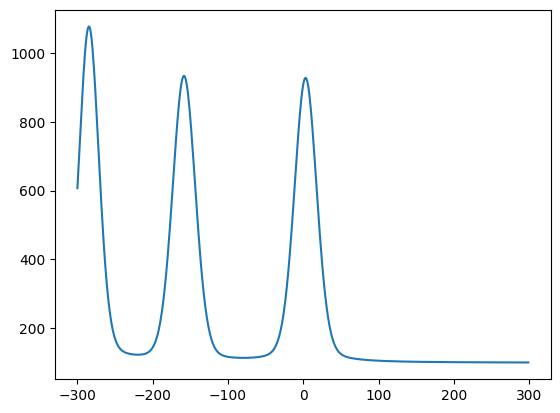

In [90]:
from EMPeaks import GaussianMixture
from EMPeaks import PseudoVoigtMixture
import numpy as np
import matplotlib.pyplot as plt
test = GaussianMixture.GaussianMixtureModel(K=3)
test = PseudoVoigtMixture.PseudoVoigtMixtureModel(K=3)
x = np.arange(-300, 300)
y = test.predict(x) * 1e+5 + 100

plt.plot(x,y)

Start deterministic annealing.
Please check class variable Dirichlet_alpha: [1.e-04 1.e-04 1.e-04 1.e-04 1.e-04 1.e-04 1.e-04 1.e-04 1.e-04 1.e-04
 1.e+00]
If Dirichlet_alpha is one, no sparsity is introduced.
Average of data intensity:  261.79512050658013
Debug [3.        3.5490282 4.0980564 4.6470846 5.1961128]
[157.0770723   44.36950652  12.53303923   3.54020328   1.        ]
Stage Temperature: 157.07707230394809:
-6681.155771264495
background: uniform
**** Start spectrum fitting via EM algorithm ****
<< Start fitting via Adapted EM Algorithm. >>
EORROR!!! [1.37233490e+02 1.66485258e+02 1.26911418e+02 1.01631038e+02
 6.16989642e+01 2.27850542e+02 4.77859823e+01 1.24403405e+01
 5.74252094e+01 6.03863271e+01 1.51429959e-01]
> iteration #  0, LL=-6.13275855e+03, residual=8.208e-02, elapsed time:  0.00 s
EORROR!!! [1.61734687e+02 1.34791225e+02 1.29266466e+02 1.05890907e+02
 5.81563135e+01 2.36882859e+02 4.19472348e+01 1.02120133e+01
 5.97227483e+01 6.12302198e+01 1.65325865e-01]
EORROR

/Users/yasunobu/Desktop/EMPeaks/EMPeaks/EMCore/_em_core.py:224: RuntimeWarning: invalid value encountered in log
  return np.sum(intensity * np.log(self.predict(x) + 1e-200))


NameError: name 'exit' is not defined

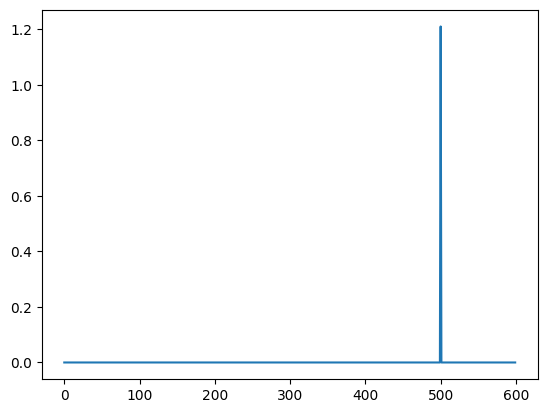

In [92]:
K=10
mm = GaussianMixture.GaussianMixtureModel(K=K, background='uniform')
for i in range(K):
    mm.model[i].mu = x.min() + i * (x.max() - x.min())/K

mm.Dirichlet_alpha = 1e-4 * np.ones(mm.K_all)
mm.Dirichlet_alpha[-1] = 1
mm.deterministic_annealing(x,y, temp0=3, stdout=True)
mm.plot(x,y)

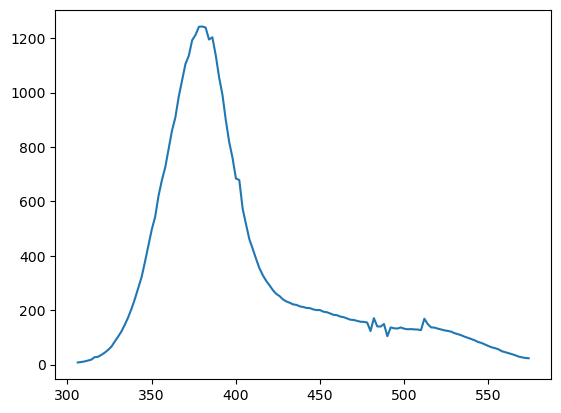

* Starting Trial #   0
background: none
**** Start spectrum fitting via Least-Square algorithm ****
Starting TSDC fitting via least square method.
Fitting parameters are {Ea, Tp, pi, and N_tot.}
   non-linear least-square optimization is successfully finished.
            RMSE:      1.367899e+01
    Elapsed time:      2.034287e-01 s

Estimated model parameters and scores are following:
   Ea:       0.716 eV        0.709 eV        0.487 eV        0.489 eV        
   tau0:     5.058e-08 s     1.884e-07 s     7.912e-04 s     7.303e-03 s     
   N_tot:   8.559e+04 
   N:       3.682e+04       2.072e+04       1.361e+04       1.444e+04       
   pi:       4.302e-01       2.421e-01       1.590e-01       1.687e-01       
   RMSE:     1.36789903e+01

* Starting Trial #   1
background: none
**** Start spectrum fitting via Least-Square algorithm ****
Starting TSDC fitting via least square method.
Fitting parameters are {Ea, Tp, pi, and N_tot.}
   non-linear least-square optimization is successful

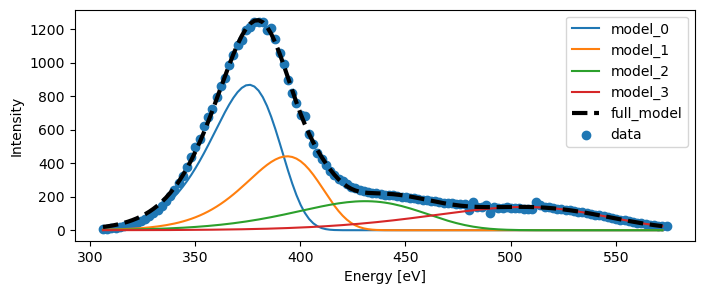

* Starting Trial #   0
background: none
**** Start spectrum fitting via EM algorithm ****
<< Start fitting via Adapted EM Algorithm. >>
A component does not have a physical solution of MLE. Initializing again.
A component does not have a physical solution of MLE. Initializing again.
A component does not have a physical solution of MLE. Initializing again.
A component does not have a physical solution of MLE. Initializing again.
A component does not have a physical solution of MLE. Initializing again.
A component does not have a physical solution of MLE. Initializing again.
A component does not have a physical solution of MLE. Initializing again.
A component does not have a physical solution of MLE. Initializing again.
A component does not have a physical solution of MLE. Initializing again.
A component does not have a physical solution of MLE. Initializing again.
A component does not have a physical solution of MLE. Initializing again.
A component does not have a physical solution of M

/Users/yasunobu/Documents/GitHub/EMPeaks/EMPeaks/TSDCMixture/_tsdc.py:319: RuntimeWarning: divide by zero encountered in log10
  return np.log10(f_sum(E, T, Y)) - np.log10(beta * b) - np.log10(g_sum) + np.log10(beta * a)
/Users/yasunobu/Documents/GitHub/EMPeaks/EMPeaks/TSDCMixture/_tsdc.py:319: RuntimeWarning: invalid value encountered in scalar subtract
  return np.log10(f_sum(E, T, Y)) - np.log10(beta * b) - np.log10(g_sum) + np.log10(beta * a)


A component does not have a physical solution of MLE. Initializing again.
A component does not have a physical solution of MLE. Initializing again.
A component does not have a physical solution of MLE. Initializing again.
A component does not have a physical solution of MLE. Initializing again.
A component does not have a physical solution of MLE. Initializing again.
A component does not have a physical solution of MLE. Initializing again.
A component does not have a physical solution of MLE. Initializing again.
A component does not have a physical solution of MLE. Initializing again.
A component does not have a physical solution of MLE. Initializing again.
A component does not have a physical solution of MLE. Initializing again.
A component does not have a physical solution of MLE. Initializing again.
A component does not have a physical solution of MLE. Initializing again.
A component does not have a physical solution of MLE. Initializing again.
A component does not have a physical s

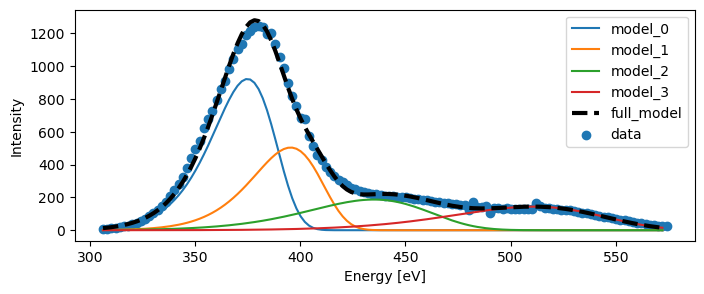

In [3]:
from EMPeaks import TSDCMixture

tsdc = TSDCMixture.TSDCMixtureModel()
examples = TSDCMixture.Tests.Example(K=4)

#examples.leastsq()
#examples.adapted_em()
#examples.leastsq_tau0()
examples.experimental_data(4, "OHA_1.csv")

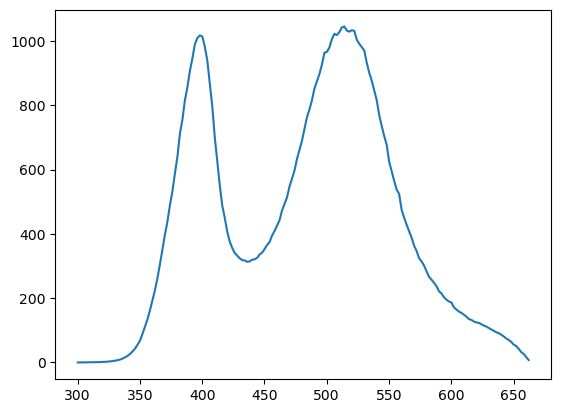

* Starting Trial #   0
background: none
**** Start spectrum fitting via Least-Square algorithm ****
Starting TSDC fitting via least square method.
Fitting parameters are {Ea, Tp, pi, and N_tot.}
   non-linear least-square optimization is successfully finished.
            RMSE:      1.129805e+01
    Elapsed time:      1.085649e-01 s

Estimated model parameters and scores are following:
   Ea:       0.860 eV        0.792 eV        0.626 eV        0.427 eV        
   tau0:     2.094e-09 s     7.494e-08 s     3.058e-04 s     1.064e-01 s     
   N_tot:   1.541e+05 
   N:       3.464e+04       8.566e+03       7.395e+04       3.696e+04       
   pi:       2.248e-01       5.558e-02       4.798e-01       2.398e-01       
   RMSE:     1.12980463e+01

* Starting Trial #   1
background: none
**** Start spectrum fitting via Least-Square algorithm ****
Starting TSDC fitting via least square method.
Fitting parameters are {Ea, Tp, pi, and N_tot.}
   non-linear least-square optimization is successful

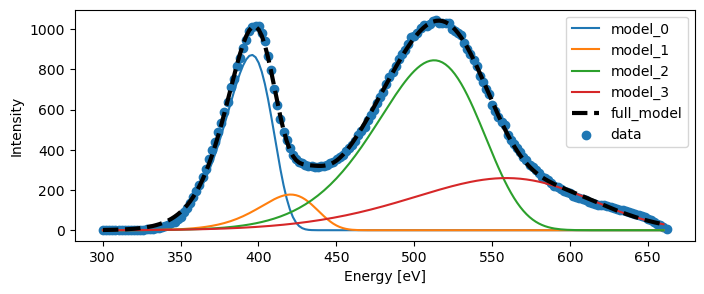

* Starting Trial #   0
background: none
**** Start spectrum fitting via EM algorithm ****
<< Start fitting via Adapted EM Algorithm. >>
Convergence is achieved at iter. 452, elapsed time  1.53 s
   LogLikelihood:     -4.24868715e+05
        residual:      9.98614954e-09
<< Optimizing normalization factor by using least square method. >>
init 153697.1370753
   non-linear least-square optimization is successfully finished.
            RMSE:      1.557841e+01
    Elapsed time:      1.024961e-03 s

* Starting Trial #   1
background: none
**** Start spectrum fitting via EM algorithm ****
<< Start fitting via Adapted EM Algorithm. >>
>>> Convergence is not achieved within the iteration of 1000, elapsed time:  3.49 s
   LogLikelihood:      -4.24879689e+05
        residual:       4.89677124e-08
<< Optimizing normalization factor by using least square method. >>
init 153697.1370753
   non-linear least-square optimization is successfully finished.
            RMSE:      1.563936e+01
    Elapsed 

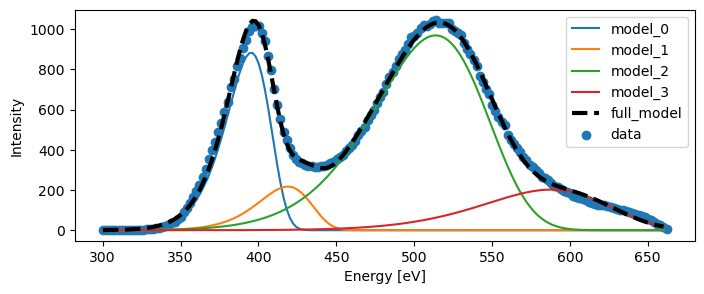

In [7]:
examples.experimental_data(4, "OHA_2.csv")

In [55]:
tsdc_exp = TSDCMixture.TSDCMixtureModel(K=4,beta=0.0833,T_min=300, T_max=600)
tsdc_exp.dT = 2.0
Ea = [0.755,0.25,0.97,1.3]
tau0 = [2.0E-8,0.65,6.5E-8,2E-10]
P0 = [6.0E+5, 3.7E+5,6.5E+4, 5.0E+4]
for i in range(4):
    tsdc_exp.N[i] = P0[i]
    tsdc_exp.N_tot = np.sum(P0)
    tsdc_exp.pi[i] = P0[i]/np.sum(P0)
    tsdc_exp.model[i].Ea = Ea[i]
    tsdc_exp.model[i].tau0 = tau0[i]
    tsdc_exp.model[i].Tp = tsdc_exp.model[i].get_Tp()
    tsdc_exp.model[i].P0 = P0[i]
print([tsdc_exp.model[i].Tp for i in range(4)])

[380.62707977198863, 414.5796412311132, 507.8272831301782, 542.8496356488238]


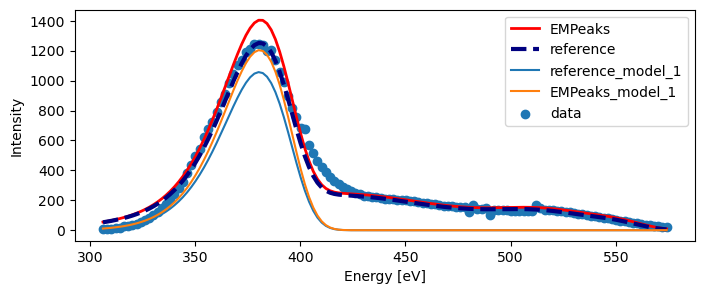

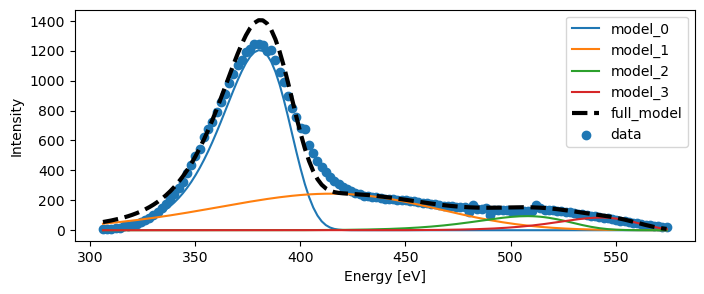

In [92]:
import numpy as np
import matplotlib.pyplot as plt

T, intensity, model_1, model_2, model_3, model_4 = np.loadtxt("OHA_1.csv", delimiter=',', unpack=True, skiprows=1)
reference = (model_1+model_2+model_3+model_4)*1000
intensity = intensity*1000
T=T+273.15
int = tsdc_exp.predict(T)*np.sum(P0)*0.0833

plt.figure(figsize=(8,3))
plt.plot(T, int, 'red', linewidth=2,  label='EMPeaks')
plt.plot(T, reference, 'navy', ls='--', label = 'reference', linewidth=3)
plt.plot(T, model_1*1000, label = 'reference_model_1')
tsdc_exp.model[0].plot(T, label = 'EMPeaks_model_1')
plt.scatter(T, intensity,  label='data')
plt.xlabel('Energy [eV]')
plt.ylabel('Intensity')
plt.legend()
plt.show()

plt.figure(figsize=(8,3))
for i in range(4):
    tsdc_exp.model[i].plot(T, label='model_'+str(i))
plt.plot(T, int, 'black', linewidth=3, ls='--', label='full_model')
plt.scatter(T, intensity,  label='data')
plt.xlabel('Energy [eV]')
plt.ylabel('Intensity')
plt.legend()
plt.show()


In [99]:
np.sqrt(np.mean([(reference[i]-intensity[i])**2 for i in range(len(reference))]))

45.87586974224571